# Basic Neural Networks
This file will go through the same dataset as the basic linear regression file except we will be using a shallow neural network to better fit the data. Again, the majority of this work is either copied or based off of a file that was provided to us by Braxton Osting. All credit due to him for laying this out for us in class.

Import necessary packages

The random seed is set for reproducibility of the results that were seen in class.

In [10]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

torch.manual_seed(0)

This defines the neural network model that we want to use. We will use a size 16 neural network and the ReLU function, which is standard for most neural networks.

In [11]:
model = nn.Sequential(
    nn.Linear(1, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
)
model

Sequential(
  (0): Linear(in_features=1, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=1, bias=True)
)

Now we want to count the number of parameters so that we can compare it across models in the future.

In [12]:
sum(p.numel() for p in model.parameters())

49

Now we are going to import the dataset. In this case we need to standardize the predictor or else the neural network will fail to train.

In [13]:
df = sns.load_dataset("mpg").dropna(subset=["horsepower"])
h = df.horsepower.values.astype(np.float32)
y = df.mpg.values.astype(np.float32)

mu, sd = h.mean(), h.std()
X = torch.tensor((h - mu) / sd).unsqueeze(1)   # shape (392, 1)
Y = torch.tensor(y).unsqueeze(1)
print(X.shape, Y.shape)

torch.Size([392, 1]) torch.Size([392, 1])


We will now train our data using Adam, which for now we are instructed to treat as a black box.

In [14]:
opt = torch.optim.Adam(model.parameters(), lr=0.05)
lossfn = nn.MSELoss()

for epoch in range(2000):
    opt.zero_grad()
    loss = lossfn(model(X), Y)
    loss.backward()
    opt.step()
    if epoch % 400 == 0:
        print(f"epoch {epoch:5d}   loss {loss.item():.4f}")

print(f"final MSE {loss.item():.4f}")

epoch     0   loss 610.0450
epoch   400   loss 18.5693
epoch   800   loss 18.5007
epoch  1200   loss 18.4316
epoch  1600   loss 18.4172
final MSE 18.4141


As with the previous example, and all model predictions, we want to know how good it is so we will now calculate RMSE, MAE, and $R^2$ for our model along with printing the results from our linear regression model that we calculated in a previous lecture and also running a regression for a quadratic model for further comparison.

In [15]:
with torch.no_grad():
    yhat = model(X).squeeze().numpy()

lin  = np.polyfit(h, y, 1)
quad = np.polyfit(h, y, 2)

def scores(pred):
    r = y - pred
    return (np.sqrt(np.mean(r**2)),
            np.mean(np.abs(r)),
            1 - np.sum(r**2) / np.sum((y - y.mean())**2))

rows = [("linear (L02)",  2, *scores(np.polyval(lin,  h))),
        ("quadratic",     3, *scores(np.polyval(quad, h))),
        (f"NN, m={16}", sum(p.numel() for p in model.parameters()), *scores(yhat))]

insample = pd.DataFrame(rows, columns=["model", "par.", "RMSE", "MAE", "R2"])
print(insample.round({"RMSE": 3, "MAE": 3, "R2": 3}).to_string(index=False))

       model  par.  RMSE   MAE    R2
linear (L02)     2 4.893 3.828 0.606
   quadratic     3 4.357 3.249 0.688
    NN, m=16    49 4.291 3.190 0.697


The NN is piecewise linear so we would expect it to have better results than the other prediction models. However, we don't expect it to be earth-shatteringly better because the dataset is not very complex. We will see more substantial results as complexity increases.

We will now plot the prediction model on the dataset as we did previously. We have also plotted the "kinks" which further explains that the model is piecewise linear. The best advantage to the NN is the fact that it optimized where the kinks should be instead of us setting them ourselves. One of the more interesting results (I think) is that there is a kink at 100 and 100.2 so there is a single function that only takes inputs between [100,100.2] which is not something we would be able to optimize by visually inspecting the data.

kinks inside the data range: [100.  100.2 153.  208. ]


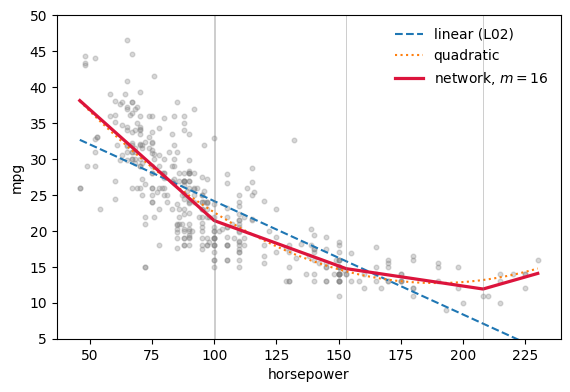

In [16]:
g = np.linspace(h.min(), h.max(), 400).astype(np.float32)
with torch.no_grad():
    gp = model(torch.tensor((g - mu) / sd).unsqueeze(1)).squeeze().numpy()

W1 = model[0].weight.detach().numpy().ravel()
B1 = model[0].bias.detach().numpy()
kinks = mu - sd * B1 / W1
kinks = np.unique(np.round(kinks[(kinks > h.min()) & (kinks < h.max())], 1))
print("kinks inside the data range:", kinks)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.scatter(h, y, s=11, alpha=0.3, color="gray")
ax.plot(g, np.polyval(lin, g),  ls="--", lw=1.5, label="linear (L02)")
ax.plot(g, np.polyval(quad, g), ls=":",  lw=1.5, label="quadratic")
ax.plot(g, gp, color="crimson", lw=2.3, label="network, $m=16$")
for k in kinks:
    ax.axvline(k, color="gray", lw=0.6, alpha=0.45)
ax.set_ylim(5, 50); ax.set_xlabel("horsepower"); ax.set_ylabel("mpg")
ax.legend(frameon=False); plt.show()

Cross-validation is really the best way to determine which model is better so we will use a 80/20 split and compare the three models.

In [17]:
def test_scores(seed):
    """Refit everything on 80% and score RMSE on the held-out 20%."""
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(y)); n = int(0.8 * len(y))
    tr, te = idx[:n], idx[n:]
    rmse = lambda a, b: float(np.sqrt(np.mean((a - b)**2)))

    out = {"linear (L02)": rmse(np.polyval(np.polyfit(h[tr], y[tr], 1), h[te]), y[te]),
           "quadratic":    rmse(np.polyval(np.polyfit(h[tr], y[tr], 2), h[te]), y[te])}

    torch.manual_seed(seed)
    m_, s_ = h[tr].mean(), h[tr].std()
    Xtr = torch.tensor((h[tr] - m_) / s_).unsqueeze(1)
    Ytr = torch.tensor(y[tr]).unsqueeze(1)
    Xte = torch.tensor((h[te] - m_) / s_).unsqueeze(1)
    net = nn.Sequential(nn.Linear(1, 16), nn.ReLU(), nn.Linear(16, 1))
    o = torch.optim.Adam(net.parameters(), lr=0.05); f = nn.MSELoss()
    for _ in range(2000):
        o.zero_grad(); l = f(net(Xtr), Ytr); l.backward(); o.step()
    with torch.no_grad():
        out["NN, m=16"] = rmse(net(Xte).squeeze().numpy(), y[te])
    return out

res = pd.DataFrame([test_scores(s) for s in range(10)])
heldout = pd.DataFrame({"RMSE": res.mean(), "sd": res.std()}).rename_axis("model").reset_index()
print(heldout.round(2).to_string(index=False))

       model  RMSE   sd
linear (L02)  4.96 0.24
   quadratic  4.44 0.34
    NN, m=16  4.45 0.34


We can see that while the NN outperforms the linear model fairly significantly, it does not outperform the quadratic model despite taking in 16x as many parameters. If needing to choose between these three options, I would certainly select the quadratic model as it requires less computing power and gets us a similar result to a neural network. Again, as complexity of a dataset increases, certainly in higher-dimensions, we will see that the neural network is the best option.